/tmp/ipykernel_14811/160439676.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_14811/160439676.py:40: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  source = source.resample("24H").last()
/tmp/ipykernel_14811/160439676.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_14811/160439676.py:40: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  source = source.resample("24H").last()
/tmp/ipykernel_14811/160439676.py:38: UserWarning: Cou

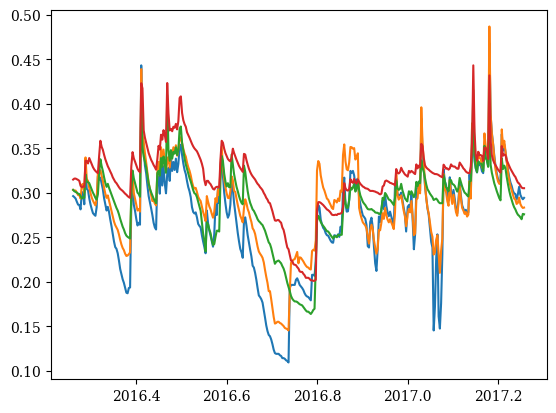

4


In [17]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path
import os
import sys
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)
from pathlib import Path
home = Path.home()
subdir = home / "src" / "at-gpflow" / "experiments" / "soil-moisture" / "Wageningen" ## or whatever folder at-gpflow lives in
at_dir = home / "src" / "at-gpflow"


sys.path.append(str(at_dir))
sys.path.append(str(subdir))
BASE = str(subdir)

# Experiment 1: different substations using multiple depths
station_indices = ["04", "04", "01", "01"]
depths = [5, 10, 10, 20]
substations = []

# Experiment 2: different substations at the same depth
# station_indices = [f"0{d}" for d in range(1, 6)]
# depths = [5 for d in range(1, 6)]
# substations = []

# # Experiment 3: same substation, different depths
# station_indices = [f"15" for d in range(1, 6)]
# depths = [5, 10, 20, 40, 80]

substations = []
for station, depth in zip(station_indices, depths):

    source = pd.read_csv(BASE+f"/data/station_data/RM_SM_{station}_calibrated.csv")
    source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
    source.index = source["Measurement Time"]
    source = source.resample("24H").last()

    source['decimal_year'] = source['Measurement Time'].dt.year + (source['Measurement Time'].dt.dayofyear - 1) / 365.25
    source.index = source["decimal_year"]
    substations.append(source)

    plt.plot(source.index, source[f"{depth} cm VWC [m3/m3]"])
plt.show()

print(len(substations))


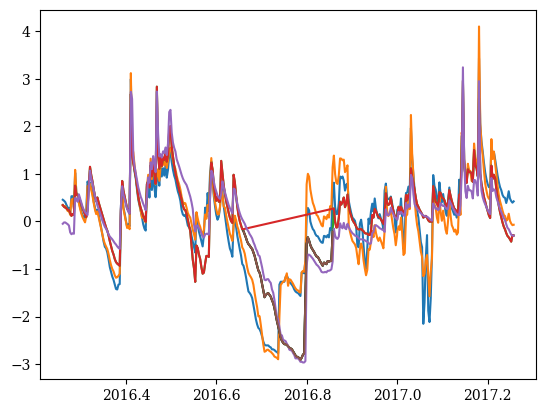

1391


In [18]:
condition_index = 2
data_X = []
data_Y = []

for i, (depth, data) in enumerate(zip(depths, substations)):
    Ay = data[f"{depth} cm VWC [m3/m3]"].to_numpy().reshape(-1, 1) 
    Ax = data.index.to_numpy().reshape(-1, 1)
    Ax = Ax[~np.isnan(Ay)].reshape(-1, 1)
    Ay = Ay[~np.isnan(Ay)].reshape(-1, 1)
    Ay = (Ay - Ay.mean()) / np.std(Ay)

    plt.plot(Ax, Ay)
    if i == condition_index:
        n_test = int(0.2*len(Ax))
        start = int(2*int(len(Ax))/5)
        end = start + n_test
        Xtest, ytest = Ax[start:end], Ay[start:end]
        Ax, Ay = np.concatenate((Ax[:start], Ax[end:])), np.concatenate((Ay[:start], Ay[end:]))
        plt.plot(Ax, Ay)
        plt.plot(Xtest, ytest, color="k")
    data_X.append(np.hstack((Ax, i*np.ones_like(Ax))))
    data_Y.append(np.hstack((Ay, i*np.ones_like(Ay))))

X = np.vstack(tuple(data_X))
y = np.vstack(tuple(data_Y))
plt.plot(Xtest, ytest)
plt.show()
print(len(X))

In [19]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

model1 = ConditionalMOGP((X, y), kernel=kern, conditioning_index=condition_index, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))

gpf.utilities.print_summary(model1)
optimize(model1)
gpf.utilities.print_summary(model1)


╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value          │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────

KeyboardInterrupt: 

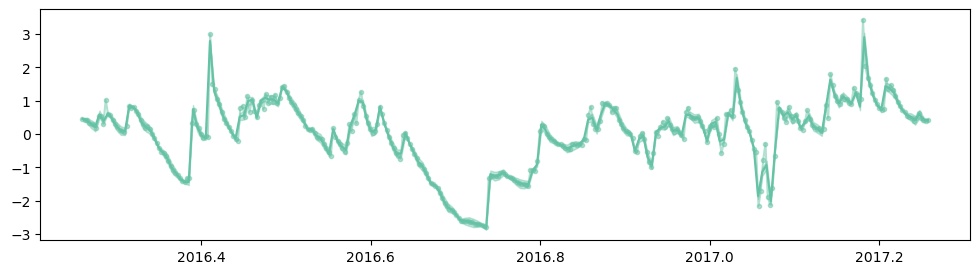

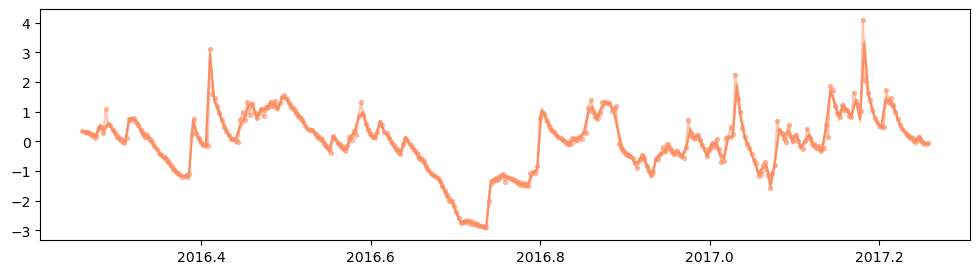

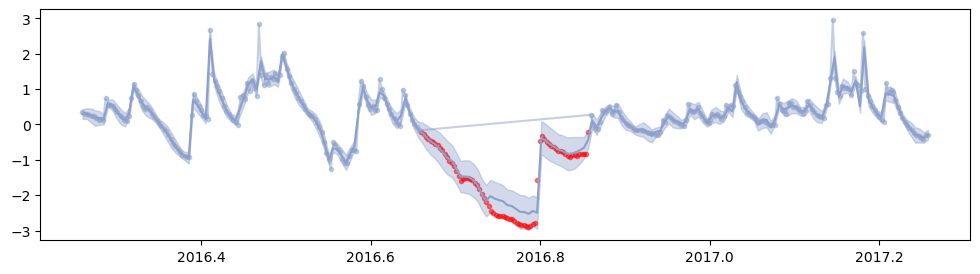

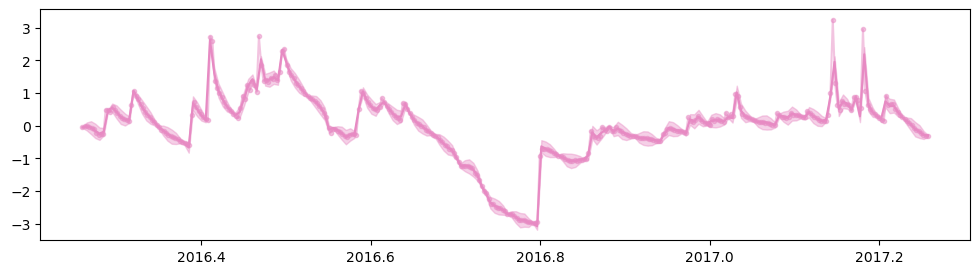

0.0551380450732915

In [ ]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model1.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model1.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()

ours_mse = mean_squared_error(ytest, fmean_test)
ours_mse

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value          │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤

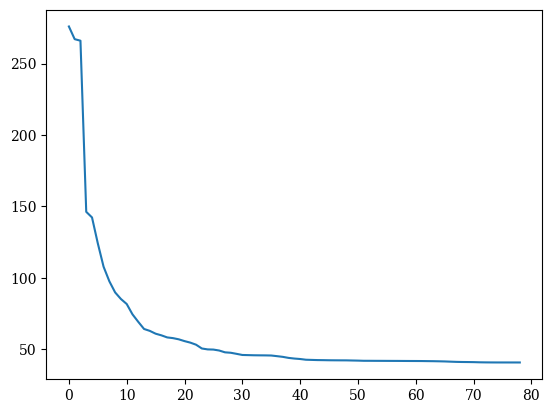

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                                              │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.01649687143031123                                │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │

In [20]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 30 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind) 
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

kern = k * coreg
#m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
model2 = SparseCMOGP((X, y), conditioning_index=condition_index, exact_target=False, kernel=kern, jitter=1e-5, inducing_variable=LMCInducingPointsBase(ivs), likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True
#gpf.set_trainable(m.likelihood.source.variance, False)
#print(model2.conditional_likelihood(decompose_likelihood=True))

gpf.utilities.print_summary(model2)
optimize(model2)
gpf.utilities.print_summary(model2)

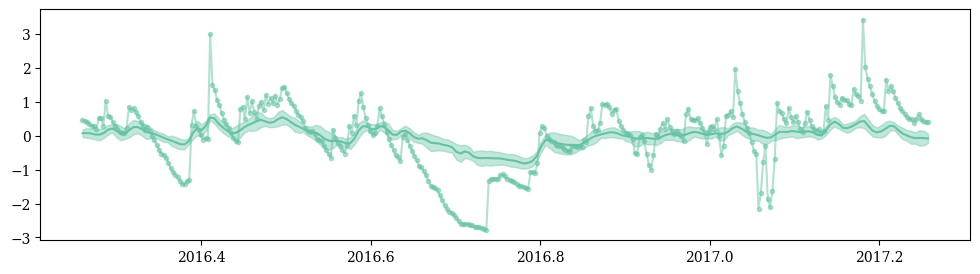

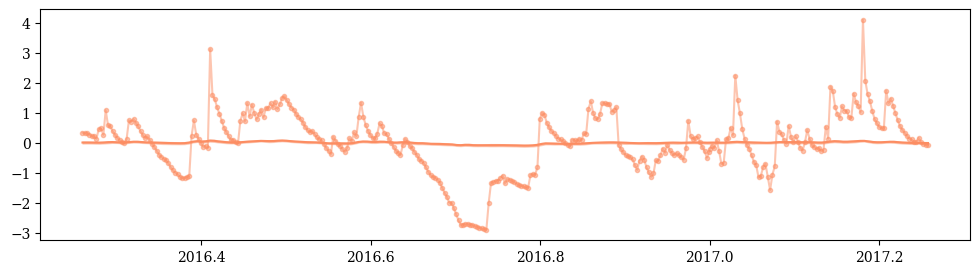

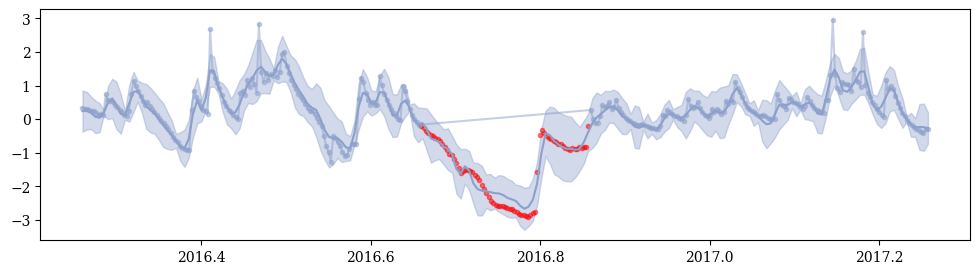

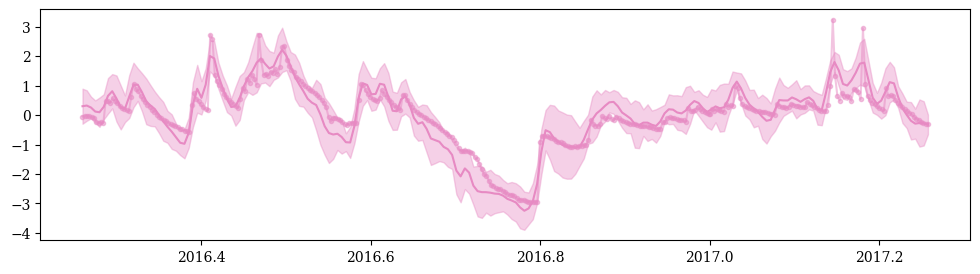

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                                              │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.01649687143031123                                │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │

0.05710993139739918

In [21]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)
colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model2.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model2.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()
gpf.utilities.print_summary(model2)

ours_mse = mean_squared_error(ytest, fmean_test)
ours_mse

In [ ]:
print(len(X))

1391


In [ ]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 30 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind)  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

l1 = gpf.likelihoods.Gaussian()
l2 = gpf.likelihoods.Gaussian()
lik = gpf.likelihoods.SwitchedLikelihood(
    [l1 if i != condition_index else l2 for i in range(output_dim)]
)
# now build the GP model as normal
model3 =  gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=LMCInducingPointsBase(ivs))


gpf.utilities.print_summary(model3)
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    model3.training_loss_closure((X, y)),
    model3.trainable_variables,
    method="L-BFGS-B",
)
gpf.utilities.print_summary(model3)

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════════╤═════════╤════════════════════════════════════════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape         │ dtype   │ value                                              │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════════╪═════════╪════════════════════════════════════════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 0.01649687143031123                                │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼────────────────────────────────────────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()         

2026-09-23 15:26:12.436280: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-09-23 15:26:12.505519: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape         │ dtype   │ value                                                │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════════╪═════════╪══════════════════════════════════════════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 0.009427053523753774                                 │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼──────────────────────────────────────────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ (

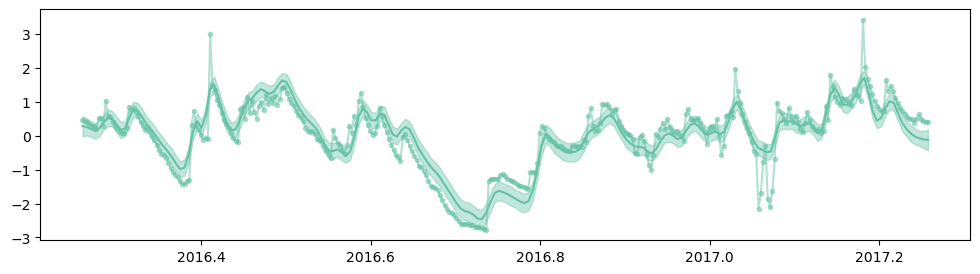

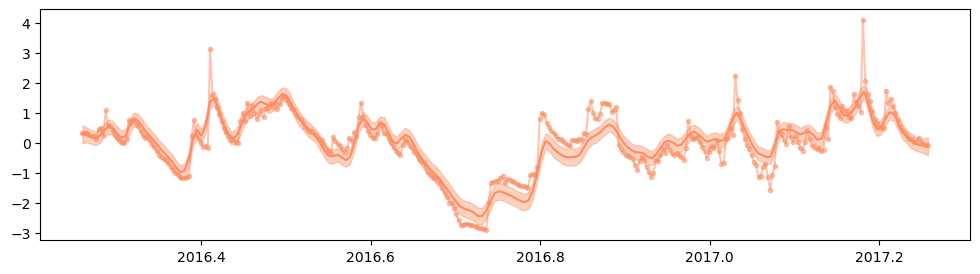

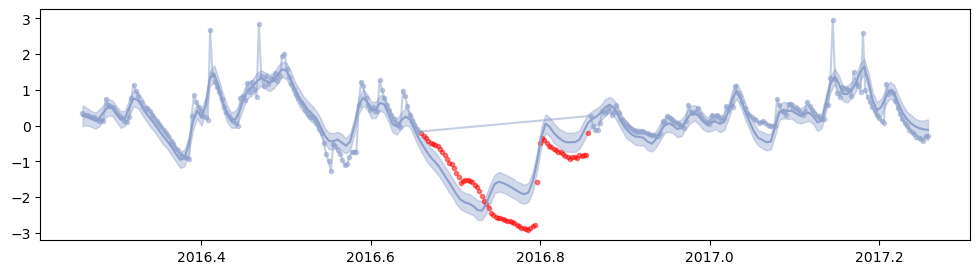

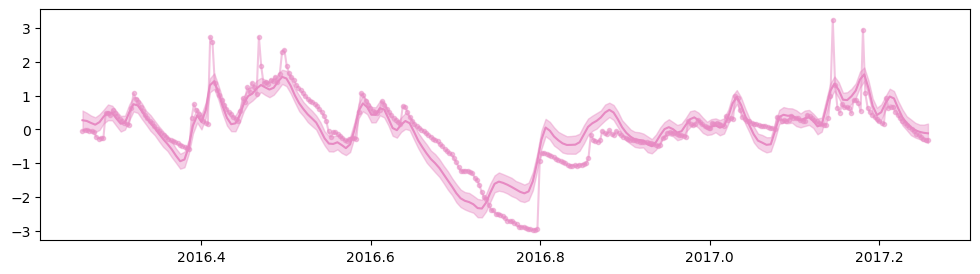

tf.Tensor(
[[-4.88176313e-01]
 [-5.92197850e-01]
 [-6.95559429e-01]
 [-7.94330967e-01]
 [-8.81563692e-01]
 [-9.52950226e-01]
 [-1.01904781e+00]
 [-1.09292576e+00]
 [-1.18390706e+00]
 [-1.28718050e+00]
 [-1.39334626e+00]
 [-1.49403886e+00]
 [-1.59238120e+00]
 [-1.69412362e+00]
 [-1.80209308e+00]
 [-1.90958741e+00]
 [-2.00439227e+00]
 [-2.07346169e+00]
 [-2.11937796e+00]
 [-2.15016009e+00]
 [-2.17105305e+00]
 [-2.19244782e+00]
 [-2.22698664e+00]
 [-2.28379668e+00]
 [-2.34901861e+00]
 [-2.39182320e+00]
 [-2.37879395e+00]
 [-2.30411740e+00]
 [-2.18206885e+00]
 [-2.02238448e+00]
 [-1.84788495e+00]
 [-1.69504405e+00]
 [-1.59909096e+00]
 [-1.56696564e+00]
 [-1.57514673e+00]
 [-1.59963597e+00]
 [-1.62748659e+00]
 [-1.65913122e+00]
 [-1.69426649e+00]
 [-1.73230684e+00]
 [-1.77307212e+00]
 [-1.81462410e+00]
 [-1.85419078e+00]
 [-1.88897223e+00]
 [-1.91372385e+00]
 [-1.91692312e+00]
 [-1.87643526e+00]
 [-1.76380933e+00]
 [-1.56019800e+00]
 [-1.28049452e+00]
 [-9.38745692e-01]
 [-5.60006954e-01]
 

0.45696191739253156

In [ ]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model3.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model3.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()

print(fmean_test)
ours_mse = mean_squared_error(ytest, fmean_test[:,0])
ours_mse

In [ ]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 50 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind)  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

l1 = gpf.likelihoods.Gaussian()
l2 = gpf.likelihoods.Gaussian()
lik = gpf.likelihoods.SwitchedLikelihood(
    [l1 if i != condition_index else l2 for i in range(output_dim)]
)

# now build the GP model as normal
model4 =  gpf.models.GPRFITC((X, y), kernel=kern, likelihood=l1, inducing_variable=LMCInducingPointsBase(ivs))


gpf.utilities.print_summary(model4)
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    model4.training_loss,
    model4.trainable_variables,
    method="L-BFGS-B",
)
gpf.utilities.print_summary(model4)

╒════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════════╕
│ name                                   │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                                  │
╞════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════════╡
│ GPRFITC.kernel.kernels[0].variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.009427053523753774                   │
├────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────────┤
│ GPRFITC.kernel.kernels[0].lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.025268944728819784                   │
├────────────────────────────────────────┼────

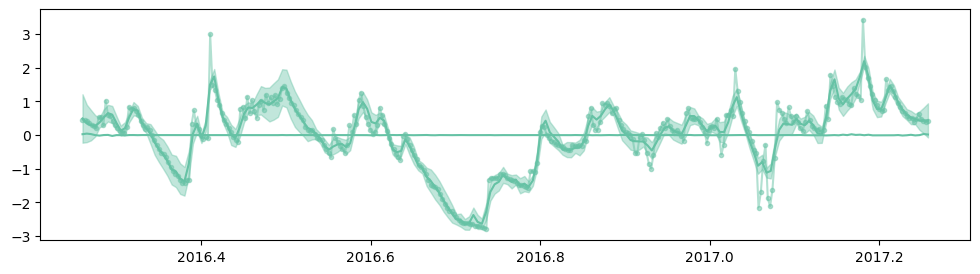

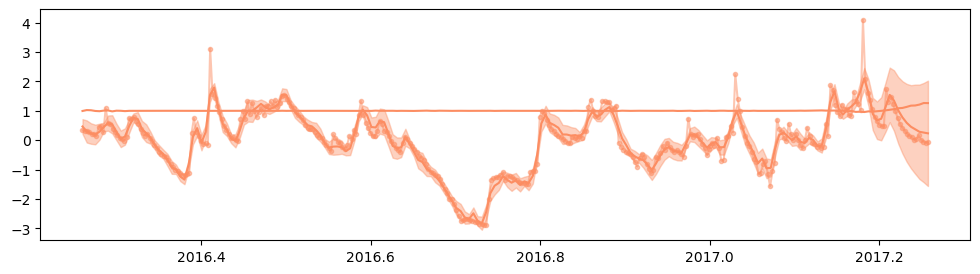

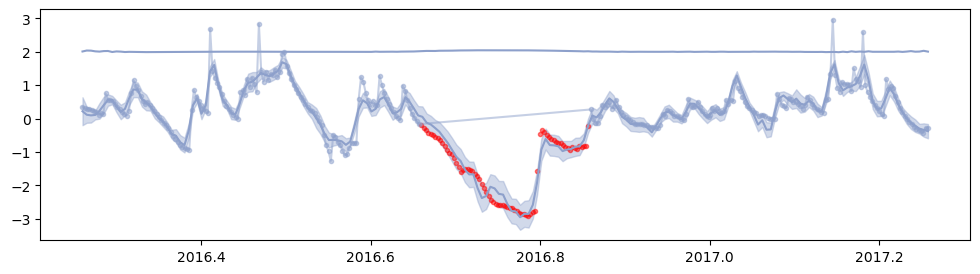

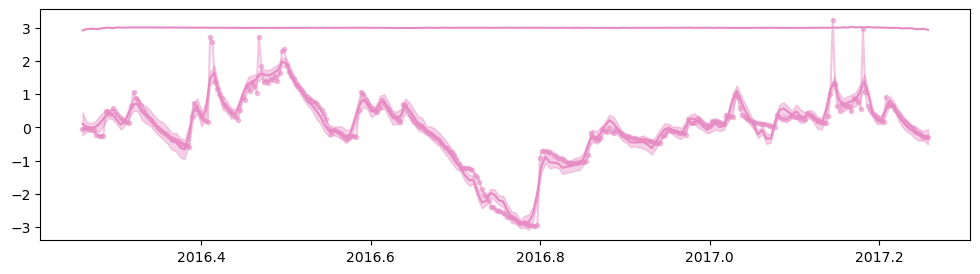

tf.Tensor(
[[ 0.06659861  2.0169    ]
 [ 0.00481801  2.02076392]
 [-0.10165674  2.02557212]
 [-0.1568097   2.02625872]
 [-0.17648946  2.02406883]
 [-0.22387005  2.02315154]
 [-0.28779831  2.02505747]
 [-0.34564695  2.02925531]
 [-0.41595995  2.03215454]
 [-0.5083856   2.03198242]
 [-0.60369678  2.03210201]
 [-0.69536605  2.03369446]
 [-0.79436261  2.03447178]
 [-0.90714961  2.03463359]
 [-1.03173188  2.03617607]
 [-1.13918482  2.03853388]
 [-1.20432706  2.04017658]
 [-1.28095986  2.04075973]
 [-1.41747214  2.04062542]
 [-1.56284881  2.04066675]
 [-1.65903564  2.04156227]
 [-1.66426826  2.0430008 ]
 [-1.64449215  2.0444601 ]
 [-1.77022557  2.0452373 ]
 [-2.02530765  2.045257  ]
 [-2.24802437  2.0451334 ]
 [-2.37675868  2.04525086]
 [-2.39777484  2.04590681]
 [-2.30710222  2.04712418]
 [-2.13886151  2.04834568]
 [-2.02671928  2.04795383]
 [-2.0453636   2.04594988]
 [-2.13964029  2.04564206]
 [-2.23603695  2.04750115]
 [-2.26154725  2.04869996]
 [-2.26676518  2.04852609]
 [-2.37605098  2.

0.06096539722935954

In [ ]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model4.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model4.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()

print(fmean_test)
ours_mse = mean_squared_error(ytest, fmean_test[:,0])
ours_mse

0.189017299658123
0.05710993139739918
473.05135192663744


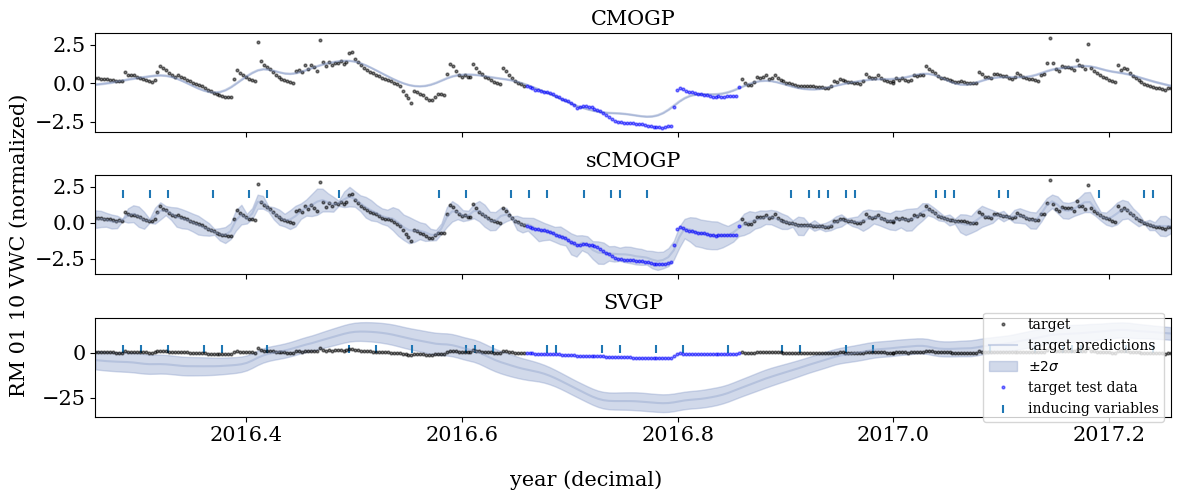

In [22]:
colors = color_sequences["Set2"]
plt.rcParams["font.family"] = "serif"
names = ["CMOGP", "sCMOGP", "SVGP"]
fig, ax = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
for i, model in enumerate([model1 ,model2, model3]):
    for index in [condition_index]:
        Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
        Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
        fmean, fvar = model.predict_f(Xplot)
        if index == condition_index:  
            fmean_test, fvar_test = model.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
            ax[i].plot(Ax[:,0], Ay[:,0], color="k", marker=".", lw=0, ms=4, alpha=0.5, label="target")
            ax[i].plot(Xplot[:,0], fmean, color=colors[index], alpha=0.4, label="target predictions")
            ax[i].fill_between(
                Xplot[:, 0],
                (fmean - 2 * np.sqrt(fvar))[:, 0],
                (fmean + 2 * np.sqrt(fvar))[:, 0],
                color=colors[index],
                alpha=0.4,
                label="$\pm 2\sigma$"
            )
            ax[i].set_xlim(np.min(Ax[:,0]), np.max(Ax[:,0]))
            ax[i].set_title(names[i], fontsize=15)
            fig.supxlabel("year (decimal)", fontsize=15)
            fig.supylabel(f"RM {station_indices[condition_index]} {depths[condition_index]} VWC (normalized)", fontsize=15)
            ax[i].tick_params(axis="both", labelsize=15)
            ax[i].plot(Xtest, ytest, "b.", ms=4, alpha=0.5, label="target test data")
            if i > 0: 
                ivs = model.inducing_variable.Z.numpy()
                ivs_target = ivs[ivs[:,1] == condition_index]
                ax[i].scatter(ivs_target, 2*np.ones_like(ivs_target), marker="|", label="inducing variables") 
            if i == 2:
                ax[i].legend(loc="right")

        mse = mean_squared_error(ytest, fmean_test[:,0])
        print(mse)
plt.tight_layout()
plt.show()